<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Relatividad-y-gravitacion/PS4_Cinem%C3%A1ticaRelativista_RG_2024_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Relatividad y Gravitación</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Problem Set 4</center></b><h2>
<h3><b><center>Cinemática Relativista</center></b><h3>
<h5><center><b>Asignada</b>: Jueves 26 de Septiembre de 2024</center><h5>
<h5><center><b>Entrega</b>: Jueves 4 de Octubre de 2024</center><h5>

juan manuel cardenas

A continuación se presentan un conjunto de ejercicios o problemas para resolver usando la teoría vista en las últimas lecciones del curso. Resuelva los ejercicios *a mano* y suba una versión digitalizada en el espacio del ítem respectivo en Google Classroom.

1. **Propiedades de la cuadriaceleración**. Partiendo de la definición general de cuadrivelocidad,
  $$
  \tilde{U_L} : \gamma(1,\vec v_L)
  $$
  y apoyándose cuando necesario en una herramienta de cálculo simbólico como `SymPy`

  a. Demuestre que la cuadriaceleación general esta dada por:

    $$
    \tilde{A_L}: \gamma^4\left(\vec{a}_L \cdot \vec{v}_L,\left(\vec{a}_L \cdot \vec{v}_L\right) \vec{v}_L+\vec{a}_L/\gamma^2\right)
    $$

  b. Usando las expresiones anteriores, muestre que la cuadrivelocidad y la cuadriaceleración siempre son perpendiculares, i.e.

    $$
    \tilde{U_L}\cdot\tilde{A_L} = 0
    $$

  c. Demuestre que la magnitud de la cuadriaceleración es:

    $$
    A_L^2 = -\alpha^2 \equiv -\gamma^6 [(\vec a_L\cdot \vec v_L)^2+\vec{a}_L^2/\gamma^2]
    $$
    
  donde llamamos a $\alpha$ la aceleración propia de la partícula, es decir, la que percibe en un sistema de referencia que se mueve con la misma partícula. Muestre además que cuando $\vec a_L||\vec v_L$

    $$
    \alpha = \gamma^3 a_L
    $$
    mientras que cuando $\vec a_L\bot\vec v_L$

    $$
    \alpha = \gamma^2 a_L
    $$
  Ofrezca una interpretación física de este último resultado.

2. **Un viaje a Proxima Centauri**. Un vehículo espacial tripulado pretende realizar un viaje hasta próxima Centauri usando un motor nuclear que tiene como característica fundamental el hecho que mantiene una cuadriaceleración propia constante $\alpha = g_L$ durante todo el recorrido. El objetivo es que los tripulantes de la nave experimenten siempre una gravedad artificial igual a la de la Tierra, g = 9.8 m/s$^2$.

  a. Usando el hecho de que $g_L^2 = -\tilde{A_L}^2$, de que la magnitud de la cuadrivelocidad es 1 y que la cuadriaceleración y la cuadrivelocidad son perpendiculares, muestre que la cuadriaceleración se puede escribir en este caso como:

  $$
  A_L^t = g_L U_L^x\\
  A_L^x = g_L U_L^t\\
  $$

  b. Partiendo de las ecuaciones anteriores muestre que:

  $$
  \frac{d^2U_L^x}{d\tau^2} = g_L^2 U_L^x
  $$
  está es la ecuación básica que describe el movimiento en una dimensión con aceleración propia constante.

  c. Resuelva la ecuación de movimiento usando como condiciones inciales $x_L(0)=0, U_L^x = 0$ y muestre que:

  $$
  \begin{aligned}
  v_L(\tau) & = \tanh(g_L\tau)\\
  x_L(\tau) & = \frac{1}{g_L}[\cosh(g_L\tau) - 1]\\
  t (\tau) & = \frac{1}{g_L}\sinh(g_L\tau)
  \end{aligned}
  $$
  haga un gráfico de $v_L$, $x_L$ como función de $\tau$ y de $t$. También haga un gráfico espacio-temporal mostrando la línea de universo y vectores de cuadrivelocidad y cuadriaceleración en puntos seleccionados de la trayectoria.

  **Ayuda**. Para encontrar el tiempo puede usar el hecho que $U_L^t = A_L^x/g_L$.


importando paquetes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-dark-palette')

Definiendo constantes

In [ ]:
# velocidad de la luz
c = 3e8 # m/s

# Cuadriaceleración propia constante
alphaL = 9.8/(3e8) # 1/segundos-luz

**Funcion para graficar los vectores cuadrivelocidad y cuadriaceleracion**

Apartir de los vectores iniciales ($t=0$) que tienen unicamente componente espacial y temporal independientemente; $U:(1,0)$ y $A:(0,α_L)$, la escala se tomo una suficiente dentro del parametro scale de quiver para que se pudieran observar adecuadamente en la grafica. y valiendose del hecho que estos vectores transforman siguiendo las transformaciones de Lorentz-Einstein's, por simplificacion se tomaron estos vectores en ($t=0$), y para encontrar su forma en otros puntos arbitrarios, usando un indice se selecciona la velocidad asociada a ese punto de la linea de mundo, al igual que su posicion, asi con el punto inicial no trasnformado dado el indice, se obtenia el punto final trasnformado y se podia graficar vectorialmente con quiver.

In [ ]:
# factor gamma
gamma = lambda u: 1 / (1 - u**2)**0.5

# Flechas iniciales (cuadriaceleración y cuadrivelocidad) en t=0
vel_inicial = np.array([1, 0])  # cuadrivel inicial (temporal)
acc_inicial = np.array([0, 1])  # cuadriacel inicial (espacial)


def graficar_vectores_TLE(i, tss, xss, vss):
    """ Rutina para Graficar vectores usando las transformadas TLEs
    bajo la config estandar, en un punto deseado, segun el indice i
    de los arreglos tss:tiempos,xss:posiciones,vss:velocidades
    """

    # Velocidad en el punto i
    u = vss[i]

    # transformación de Lorentz
    Transf = gamma(u) * np.array([[1, u],
                                  [u, 1]])

    # Aplicar transformación a flechas iniciales
    vel_transformada = Transf @ vel_inicial
    acc_transformada = Transf @ acc_inicial

    # Coordenadas originales en el punto i
    t_original = tss[i]
    x_original = xss[i]

    # Flechas transformadas en i y transladadas
    ax1.quiver([t_original], [x_original], [vel_transformada[0]], [vel_transformada[1]],
               angles='xy', scale_units='xy', scale=3e-8, width=0.01, color='orange', label='Cuadrivel')
    ax1.quiver([t_original], [x_original], [acc_transformada[0]], [acc_transformada[1]],
               angles='xy', scale_units='xy', scale=3e-8, width=0.01, color='red', label='Cuadriacel')

**Graficando las soluciones $x_L t, v_L$ hiperbolicas dependientes de $τ$**

Creando un arreglo de valores de $τ$ y definiendo las funciones hiperbolicas solucion, se graficó primero $x_L$ en funcion de $t$ y $τ$, ademas de la diferencia entre estos $t$ y $τ$. Todos los valores se trabajaron en unidades luz y segundos luz.


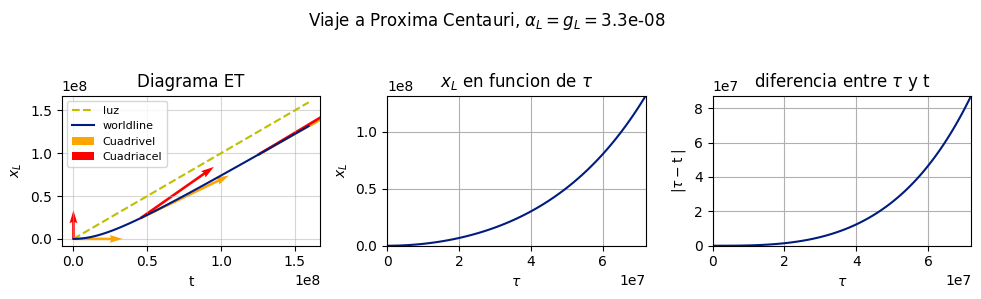

In [ ]:
# tiempos propios
taus = np.linspace(0,int(7.2e7),100)

# soluciones t, x, v [unit luz]
ts = (1/alphaL) * np.sinh(alphaL*taus)
xLs = (1/alphaL) * ( np.cosh(alphaL*taus)-1 )
vLs = np.tanh(alphaL*taus)

# grafica
fig, [ax1,ax2,ax3] = plt.subplots(1,3,figsize=(10,3))
fig.suptitle(f'Viaje a Proxima Centauri, $\\alpha_L=g_L=${alphaL:.1e}')

ax1.set_title('Diagrama ET')
ax1.plot(ts, ts, color='y',linestyle='--', label='luz')
ax1.set_ylabel("$x_L$")
ax1.set_xlabel("t")
ax1.plot(ts, xLs, label='worldline')
ax1.grid(alpha=0.5)
# felchitas
graficar_vectores_TLE(0, ts,xLs,vLs)
ax1.legend(fontsize=8)
graficar_vectores_TLE(50, ts,xLs,vLs)
graficar_vectores_TLE(89, ts,xLs,vLs)


ax2.set_title('$x_L$ en funcion de $\\tau$')
ax2.plot(taus,xLs)
ax2.set_ylabel("$x_L$")
ax2.set_xlabel("$\\tau$")
ax2.margins(0)
ax2.grid()

ax3.plot(taus,np.abs(taus-ts))
ax3.set_title('diferencia entre $\\tau$ y t')
ax3.set_ylabel("|$\\tau - $t |")
ax3.set_xlabel("$\\tau$")
ax3.margins(0)
ax3.grid()
plt.tight_layout()

**Graficas de la velocidad $v_L$ en funcion de $t$ y $τ$**

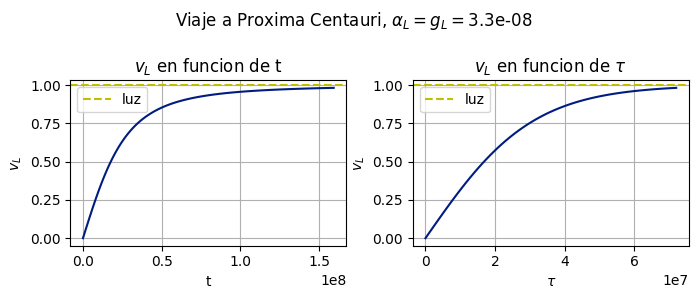

In [ ]:
# grafica
fig, [ax1,ax2] = plt.subplots(1,2,figsize=(7,3))
fig.suptitle(f'Viaje a Proxima Centauri, $\\alpha_L=g_L=${alphaL:.1e}')

ax1.set_title('$v_L$ en funcion de t')
ax1.plot(ts, vLs)
ax1.axhline(y=1, color='y', linestyle='--', label='luz')
ax1.set_ylabel("$v_L$")
ax1.set_xlabel("t")
ax1.legend()
ax1.grid()

ax2.set_title('$v_L$ en funcion de $\\tau$')
ax2.plot(taus, vLs)
ax2.axhline(y=1, color='y', linestyle='--', label='luz')
ax2.set_ylabel("$v_L$")
ax2.set_xlabel("$\\tau$")
ax2.grid()
ax2.legend()

plt.tight_layout()

Manteniendo la aceleracion propia constante durante todo el viaje, dado cierto tiempo la velocidad de la nave termina acercandose a la velocidad de la luz asintoticamente.
Ademas, variando la aceleracion propia, se encuentra que a medida que se aumenta, la nave puede llegar a su destino en menos tiempo o tiempo propio $τ$, y consigue mayores velocidades igualmente en menos tiempo, resultado esperable.

<br><br>

  d. Encuentre el tiempo medido en la Tierra y el tiempo medido en la nave necesario para alcanzar Proxima Centauri que esta a 4.3 ly manteniendo durante todo el recorrido una aceleración propia de 9.8 m/s$^2$. ¿Cuál es la velocidad máxima alcanzada por la nave?.



usando las mismas soluciones hiperbolicas, tomando la inversa de la funcion de la posicion, y reemplazando el valor de la distancia a la que se encuentra proxima centauri, se puede obtener el tiempo propio asociado a todo el viaje, y con este las demas soluciones del tiempo y la velocidad, cuyo valor final corresponde con el maximo como se pudo apreciar de la grafica anterior.

In [ ]:
# Distancia a recorrer
year = 365.25 * 86400 # segundos
xL = 4.3 * year # [s-l]

# inversa de x para enontrar tau y el resto de soluciones
tau = np.arccosh(alphaL*xL+1)/alphaL #s
t = (1/alphaL)*np.sinh(alphaL*tau) #s
vL = np.tanh(alphaL*tau) # u.l.

print("Recorrido completo con aceleracion cte\n")
print(f"alpha_L = {alphaL:.1e} 1/s-l")
print(f"x_L = {xL:.1e} s-l")
print(f"tau = {tau:.3} s = {tau/year:.4} años")
print(f"t = {t:.3} s = {t/year:.4} años")
print(f"v_L = {vL:.4} c = {vL*c:.6} m/s")

Recorrido completo con aceleracion cte

alpha_L = 3.3e-08 1/s-l
x_L = 1.4e+08 s-l
tau = 7.28e+07 s = 2.306 años
t = 1.63e+08 s = 5.18 años
v_L = 0.9829 c = 2.94874e+08 m/s


  e. Naturalmente, para hacer el viaje planteado en este problema en realidad sería necesario acelerar durante la mitad del recorrido y desacelerar durante la segunda mitad. Use un argumento de simetría para calcular cuánto tomaría el viaje (tanto en el sistema de referencia del laboratorio como en el de la nave) y cuál sería la máxima velocidad alcanzada. Haga, como en c, un gráfico espacio-temporal mostrando la línea de universo y vectores de cuadrivelocidad y cuadriaceleración en puntos seleccionados de la trayectoria.

Similarmente al punto anterior, en la primera parte del trayecto, usando la distancia media a la que se encuentra proxima centauri, se obtienen los valores del tiempo que se demora la nave al llegar a ese punto medio, su velocidad maxima y demas valores:

In [ ]:
# mitad del trayecto
xL = 4.3/2*year # [s-l]

# inversa para tau y demas solucion
tau = np.arccosh(alphaL*xL+1)/alphaL #s
t = (1/alphaL)*np.sinh(alphaL*tau) #s
vL = np.tanh(alphaL*tau) # u.l.

print("Recorrido 1r parte con aceleracion cte\n")
print(f"x_L = {xL:.1e} s-l")
print(f"tau = {tau:.1e} = {tau/year:.4} años")
print(f"t = {t/year:.4} años")
print(f"v_L maxima = {vL:.4} c = {vL*c:.2e} m/s\n")

print("\nRecorrido total compuesto (simetrico)\n")
print(f"x_L = {2*xL:.1e} s-l")
print(f"tau = {2*tau:.1e} = {2*tau/year:.4} años")
print(f"t = {2*t/year:.4} años")


Recorrido 1r parte con aceleracion cte

x_L = 6.8e+07 s-l
tau = 5.6e+07 = 1.781 años
t = 2.965 años
v_L maxima = 0.9504 c = 2.85e+08 m/s


Recorrido total compuesto (simetrico)

x_L = 1.4e+08 s-l
tau = 1.1e+08 = 3.563 años
t = 5.931 años


se demora un poco mas $5.93$ años a diferencia del punto anterior $5.18$ años, donde se uso aceleracion cte durante todo el recorrido, ademas tambien se alcanza una velocidad menor $0.95 c$ a diferencia del primero $0.98 c $

Dividiendo el trayecto en 2, la primera parte se realiza hasta la mitad de la distancia a proxima centauri con aceleracion constante, y empleando simetria en ese punto medio la segunda parte del trayecto será la misma que la primera pero invertida y trasladada.

In [ ]:
# primera parte
taus = np.linspace(0,int(tau),100)
ts = (1/alphaL) * np.sinh(alphaL*taus)
xLs = (1/alphaL) * ( np.cosh(alphaL*taus)-1 )
vLs = np.tanh(alphaL*taus)

**Criterios de Simetria**

suponiendo la mitad del trayecto tiene el mismo comportamiento que la parte final, bastaba entonces con calcular las soluciones de la primera parte y reflejarlos arreglos solucion, esto es valido y se observaba la simetria unicamente si se hacia esta reflexion respecto a $τ$ pues sus valores se definieron distribuidos uniformemente, pero al hacer la transformacion a $t$ no se conservava el distanciamiento entre valores, comprimiendose unos y separandose otros, por lo que para aplicar simetria de reflexion respecto a $t$ no bastaba con invertir las listas de los valores de $v$ o $x$, sino que tambien era necesario crear otro arreglo para los nuevos tiempos que invirtiera tambien el orden del espaciamiento en el arreglo de $t$ de la primera parte, se recurrio a una ayuda de chatgpt para este caso:

In [ ]:
"""codigo de chatgpt para invertir arreglos con espaciado desigual"""

# Calculamos las diferencias entre tiempos consecutivos
delta_ts = np.diff(ts)

# Invertimos las diferencias
delta_ts_inverted = delta_ts[::-1]

# Reconstruimos el nuevo arreglo de tiempos invertido
t_start = ts[0]  # Punto inicial para la construcción del nuevo arreglo
ts_inverted = [t_start]

# Iteramos sumando las diferencias invertidas para reconstruir el nuevo arreglo
for delta_t in delta_ts_inverted:
    ts_inverted.append(ts_inverted[-1] + delta_t)

ts_inverted = np.array(ts_inverted) + ts[-1]
xLs_inverted = -xLs[::-1] + 2*xLs[-1]

**Grafica de $x_L$ en funcion de $t$ y $τ$, recorrido compuesto**

los puntos donde se graficaron los vectores se seleccionaron arbitariamente para que se obtuviera una buena visualizacion de los vectores transformados.

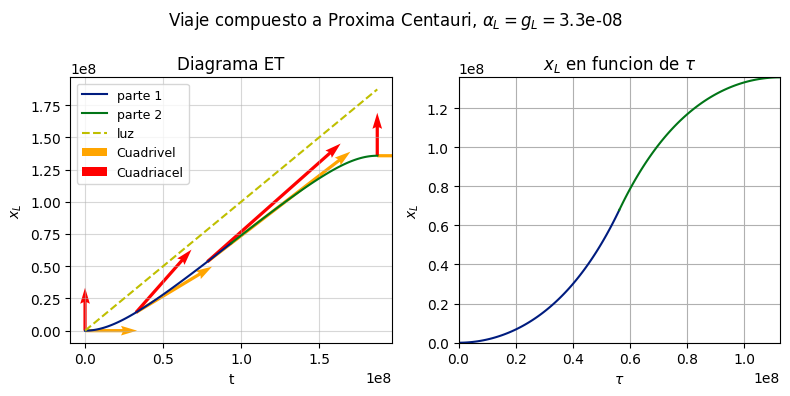

In [ ]:
# grafica
fig, [ax1,ax2] = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(f'Viaje compuesto a Proxima Centauri, $\\alpha_L=g_L=${alphaL:.1e}')

ax1.set_title('Diagrama ET')
ax1.plot(ts, xLs, label='parte 1')
ax1.plot(ts_inverted, xLs_inverted, label='parte 2')
ax1.plot(2*ts, 2*ts, color='y',linestyle='--', label='luz')
ax1.set_ylabel("$x_L$")
ax1.set_xlabel("t")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.5)

# felchitas
graficar_vectores_TLE(0, ts,xLs,vLs)
ax1.legend(fontsize=9)
graficar_vectores_TLE(50, ts,xLs,vLs)
graficar_vectores_TLE(90, ts,xLs,vLs)
graficar_vectores_TLE(99, ts_inverted,xLs_inverted,vLs[::-1])


ax2.set_title('$x_L$ en funcion de $\\tau$')
ax2.plot(taus,xLs)
ax2.plot(taus+taus[-1], -xLs[::-1]+2*xLs[-1])
ax2.set_ylabel("$x_L$")
ax2.set_xlabel("$\\tau$")
ax2.margins(0)
ax2.grid()
plt.tight_layout()

**Grafica de $v_L$ en funcion de $t$ y $τ$, recorrido compuesto**

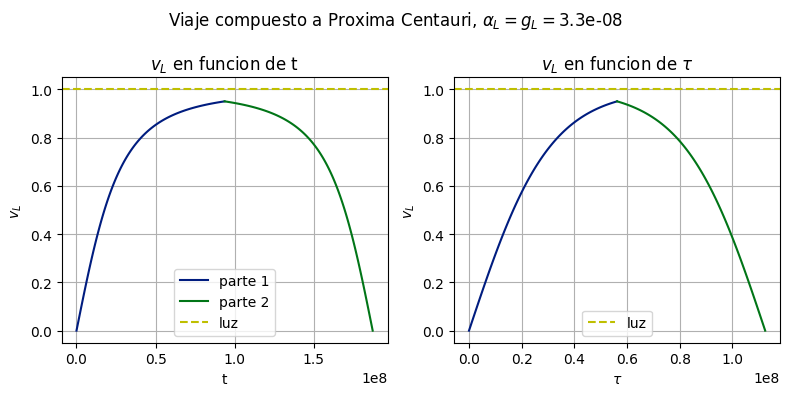

In [ ]:
# grafica de primera parte del recorrido
fig, [ax1,ax2] = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(f'Viaje compuesto a Proxima Centauri, $\\alpha_L=g_L=${alphaL:.1e}')

ax1.set_title('$v_L$ en funcion de t')
ax1.plot(ts,vLs, label='parte 1')
ax1.plot(ts_inverted, vLs[::-1], label='parte 2')
ax1.axhline(y=1, color='y', linestyle='--', label='luz')
ax1.set_ylabel("$v_L$")
ax1.set_xlabel("t")
ax1.legend()
ax1.grid()

ax2.set_title('$v_L$ en funcion de $\\tau$')
ax2.plot(taus, vLs)
ax2.plot(taus+taus[-1], vLs[::-1])
ax2.axhline(y=1, color='y', linestyle='--', label='luz')
ax2.set_ylabel("$v_L$")
ax2.set_xlabel("$\\tau$")
ax2.grid()
ax2.legend()
plt.tight_layout()

3. **Demostraciones tensoriales**.

   a. Pruebe que si $\tilde{A}$ es un tensor en un espacio normado de métrica $g_{\mu\nu}$, entonces: $A_\mu = g_{\mu\nu}A^\mu$

   b. Demuestre que los coeficientes métricos asociados con una base y su recíproca, satisfacen: $g_{\alpha\mu}g^{\mu\beta} = \delta_\alpha^\beta$

   c. Muestre que en el espacio euclídeo, dada una base $\vec{e}_i$, los elementos de la base recíproca son:

     $$
     \vec{e}^i = \frac{\vec e_j\times\vec e_k}{V}
     $$
     donde $V=\vec e_1\cdot(\vec e_2\times\vec e_3)$ y los índices $i, j, k$ forman un conjunto de mano derecha, ie. 1,2,3 o bien 2,3,1 o bien 3,1,2.

4. **Leyes de transformación de la velocidad**. El cuadrivector de velocidad $\tilde{U_L}:\gamma(1,\vec{v}_L)$, como cualquier cuadrivector transforma siguiendo las leyes de transformación generales:

  $$
\begin{aligned}
& A^{0^{\prime}}=\gamma\left(A^0-\vec{u}_L \cdot \vec{A}_L\right) \\
& \vec{A}_L^{\prime}=\vec{A}_L+\left(\frac{\gamma-1}{u_L^2} \vec{u}_L \cdot \vec{A}_L-\gamma A^0\right) \vec{u}_L
\end{aligned}
  $$

  Muestre que:

  a. Use estas reglas generales y la definición de $\tilde{U_L}$ para demostrar que la transformación del factor de Lorentz es:

   $$
   \frac{\gamma_v}{\gamma_{v^{\prime}}}=\frac{D}{\gamma_u}
   $$
   donde

   $$
   D \equiv \frac{1}{1-\vec{u}_L \cdot \vec{v}_L}
   $$

  b. Use estas reglas generales y la definición de $\tilde{U_L}$ para demostrar que la transformación general de velocidades espaciales es:

    $$
    \vec{v}_L^{\prime}=\frac{D}{\gamma_u}\left[\vec{v}_L+\left(\frac{\gamma_u-1}{u_L^2} \vec{u}_L \cdot \vec{v}_L-\gamma_u\right) \vec{u}_L\right]
    $$

  c. Toda velocidad puede descomponerse como $\vec v_L : (v_{\|L},v_{\perp L})$ donde las cantidades en el par ordenado son las componentes de $\vec v_L$ que son paralela a $u_L$ y perpendicular a ella.  Muestre que, de la ecuación anterior, estas componentes pueden escribirse como:

   $$
   \begin{aligned}
v_{\| L}^{\prime} & =D\left(v_{\| L}-u_L\right) \\
v_{\perp L}^{\prime} & =\frac{D}{\gamma} v_{\perp L}
\end{aligned}
   $$
   y que estas coinciden con las transformaciones cuando se usa la configuración estándar.
